# Procurement & Vendor Fraud Protection — Network-Graph Case Study

**Audience:** Finance / AP / Internal Audit (no data-science background assumed)
**Goal:** See, hands-on, how turning a flat invoice ledger into a *network* —
vendors, employees, and the money that flows between them — surfaces three
classic procurement fraud patterns that spreadsheet filters usually miss:

1. **Ghost vendors** — fake or shell suppliers set up to bill the company for
   goods/services that were never delivered.
2. **Split-purchase schemes** — a real need is broken into several invoices,
   each kept just under an approval threshold, to dodge a second sign-off.
3. **Collusion rings** — an employee and one or more "independent" vendors
   are secretly the same economic actor (shared bank account, address, or
   phone), and invoices sail through because the same people request and
   approve them every time.

The dataset here is **synthetic** (fabricated with Faker), built to contain
all three patterns inside ~730 otherwise normal-looking invoices — exactly
the kind of needle-in-a-haystack an AP team faces in real life.

> No prior Python experience needed to follow along — each code cell is
> annotated with what it does and *why* it matters for fraud detection.


## 1. Load the ledger

Three tables, just like a real ERP export: employees, vendors, and invoices.

In [1]:
import pandas as pd

employees = pd.read_csv("data/employees.csv")
vendors   = pd.read_csv("data/vendors.csv")
invoices  = pd.read_csv("data/invoices.csv", parse_dates=["date"])

print(f"{len(employees)} employees | {len(vendors)} vendors | {len(invoices)} invoices")
invoices.head()


25 employees | 43 vendors | 727 invoices


,invoice_id,date,vendor_id,requester_id,approver_id,amount,note
0,INV-1011,2025-01-02,V-007,EMP-009,EMP-018,3922.06,NaN
1,INV-1642,2025-01-07,V-032,EMP-000,EMP-014,20629.73,NaN
2,INV-1622,2025-01-07,V-031,EMP-020,EMP-013,12749.63,NaN
3,INV-1171,2025-01-08,V-015,EMP-022,EMP-017,7561.39,NaN
4,INV-1138,2025-01-08,V-018,EMP-007,EMP-010,4429.68,NaN


## 2. Why a network, not just a spreadsheet?

A pivot table answers "how much did we pay Vendor X?" A **network graph**
answers a different, more dangerous question: *"who is really connected to
whom?"*

We build a graph with two kinds of nodes:

- **Employee nodes** (requesters / approvers)
- **Vendor nodes**

An **edge** is drawn between an employee and a vendor every time that
employee requests or approves an invoice for that vendor. The graph reveals
structure — clusters, hubs, and isolated pairs — that is invisible when
you're scrolling through rows.


In [2]:
import networkx as nx

G = nx.Graph()

for _, e in employees.iterrows():
    G.add_node(e.employee_id, kind="employee", label=e["name"])

for _, v in vendors.iterrows():
    G.add_node(v.vendor_id, kind="vendor", label=v.vendor_name)

# Weighted edges: how many invoices connect this employee to this vendor
for role in ["requester_id", "approver_id"]:
    counts = invoices.groupby([role, "vendor_id"]).size().reset_index(name="n")
    for _, row in counts.iterrows():
        emp, ven, n = row[role], row["vendor_id"], row["n"]
        if G.has_edge(emp, ven):
            G[emp][ven]["weight"] += n
        else:
            G.add_edge(emp, ven, weight=n)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Graph: 68 nodes, 581 edges


## 3. Pattern 1 — Ghost vendors

**Red flags a network view exposes immediately:**

- Very **low degree** (only 1–2 employees ever touch this vendor — a real
  supplier usually gets ordered by several departments over a year)
- A **single requester + single rubber-stamp approver**, every time
- Missing **tax ID**, a PO Box address, or an address/phone that matches
  another vendor (or an employee)
- Invoice amounts clustered **just under an approval threshold**

We compute a simple ghost-vendor score from these signals — this is exactly
the kind of check an AI/analytics layer automates so the auditor only
reviews the short list, not all 43 vendors.


In [3]:
THRESHOLD = 10000  # second-approval threshold, illustrative

vendor_stats = []
for vid, grp in invoices.groupby("vendor_id"):
    requesters = grp["requester_id"].nunique()
    approvers = grp["approver_id"].nunique()
    n_inv = len(grp)
    pct_near_threshold = (grp["amount"].between(0.85 * THRESHOLD, THRESHOLD)).mean()
    vendor_stats.append({
        "vendor_id": vid,
        "n_invoices": n_inv,
        "distinct_requesters": requesters,
        "distinct_approvers": approvers,
        "pct_near_threshold": round(pct_near_threshold, 2),
    })

vstats = pd.DataFrame(vendor_stats).merge(vendors, on="vendor_id")
vstats["missing_tax_id"] = vstats["tax_id"].isna() | (vstats["tax_id"] == "")
vstats["po_box"] = vstats["address"].str.contains("PO Box", case=False, na=False)

# Ghost-vendor score: single requester/approver + high concentration near
# threshold + missing tax ID / PO box  -> higher = more suspicious
vstats["ghost_score"] = (
    (vstats["distinct_requesters"] <= 1).astype(int)
    + (vstats["distinct_approvers"] <= 1).astype(int)
    + (vstats["pct_near_threshold"] >= 0.5).astype(int)
    + vstats["missing_tax_id"].astype(int)
    + vstats["po_box"].astype(int)
)

vstats.sort_values("ghost_score", ascending=False)[
    ["vendor_id", "vendor_name", "n_invoices", "distinct_requesters",
     "distinct_approvers", "pct_near_threshold", "missing_tax_id",
     "po_box", "ghost_score"]
].head(8)


,vendor_id,vendor_name,n_invoices,distinct_requesters,distinct_approvers,pct_near_threshold,missing_tax_id,po_box,ghost_score
36,V-GH2,Media Services Inc,5,1,1,0.60,True,True,5
37,V-GH3,Defense Services Inc,4,1,1,0.75,True,True,5
35,V-GH1,Health Services Inc,5,1,1,0.60,True,False,4
42,V-SPLIT,Summit Facilities Maintenance LLC,25,1,1,1.00,False,False,3
4,V-004,Moore-Bass,20,13,8,0.10,False,False,0
5,V-005,"Garcia, Deleon and Henson",25,16,8,0.04,False,False,0
6,V-006,Fletcher Inc,19,15,8,0.05,False,False,0
3,V-003,Mitchell-Horton,17,14,7,0.12,False,False,0


Notice `V-GH1`, `V-GH2`, `V-GH3` land at the top with a ghost score of 4–5:
one requester, one approver, invoices bunched just under the threshold, and
missing/incomplete tax registration. That combination on its own would be
easy to miss in a spend report sorted by dollar amount — these vendors are
*small*. The network view catches them because of **who** touches them, not
**how much** they bill.


## 4. Pattern 2 — Split-purchase schemes

A split purchase hides in plain sight: no single invoice looks alarming,
but the *same requester* files *several* invoices to the *same vendor*
*close together in time*, each just under the threshold that would trigger
extra scrutiny.

We look for exactly that shape: requester–vendor pairs with repeated
invoices within a rolling 7-day window, each near (but under) the threshold.


In [4]:
invoices_sorted = invoices.sort_values(["requester_id", "vendor_id", "date"])
flags = []

for (req, ven), grp in invoices_sorted.groupby(["requester_id", "vendor_id"]):
    grp = grp.sort_values("date")
    dates = grp["date"].tolist()
    amounts = grp["amount"].tolist()
    for i in range(len(dates)):
        window = grp[(grp["date"] >= dates[i]) & (grp["date"] <= dates[i] + pd.Timedelta(days=7))]
        if len(window) >= 2 and (window["amount"] < THRESHOLD).all() and window["amount"].sum() > THRESHOLD:
            flags.append({
                "requester_id": req,
                "vendor_id": ven,
                "window_start": dates[i].date(),
                "invoices_in_window": len(window),
                "combined_amount": round(window["amount"].sum(), 2),
            })

split_flags = pd.DataFrame(flags).drop_duplicates(subset=["requester_id", "vendor_id", "window_start"])
split_summary = (split_flags.groupby(["requester_id", "vendor_id"])
                  .agg(bursts=("window_start", "nunique"),
                       max_combined=("combined_amount", "max"))
                  .reset_index()
                  .sort_values("bursts", ascending=False))
split_summary.head(10)


,requester_id,vendor_id,bursts,max_combined
1,EMP-013,V-SPLIT,15,29192.79
0,EMP-007,V-GH1,1,17723.65
2,EMP-017,V-014,1,11692.59


`EMP-013` → `V-SPLIT` should dominate this table: repeated 7-day bursts
where 2–3 invoices, each individually under $10,000, combine to well over
it. Any one of those invoices would clear a normal approval workflow — the
pattern only shows up once you look at **behavior over time for a
requester–vendor pair**, which is exactly what a rules engine or graph
temporal analysis is built to watch for.


## 5. Pattern 3 — Collusion rings

This is where network analysis earns its keep. Individually, four
"different" logistics vendors look unrelated. But if we draw an edge
between any two vendors that **share a bank account, phone number, or
address**, the fraud ring reveals itself as a **tight cluster** — and we can
overlay which employees exclusively deal with that cluster.


In [5]:
# Vendor-to-vendor similarity graph: an edge = shared bank account / phone / address
V = nx.Graph()
for _, v in vendors.iterrows():
    V.add_node(v.vendor_id, label=v.vendor_name)

attrs = ["bank_account", "phone", "address"]
for attr in attrs:
    for val, grp in vendors.groupby(attr):
        if len(grp) > 1 and val not in ("", None):
            ids = grp["vendor_id"].tolist()
            for i in range(len(ids)):
                for j in range(i + 1, len(ids)):
                    if V.has_edge(ids[i], ids[j]):
                        V[ids[i]][ids[j]]["shared"].append(attr)
                    else:
                        V.add_edge(ids[i], ids[j], shared=[attr])

# Connected components of size > 1 are potential collusion clusters
clusters = [c for c in nx.connected_components(V) if len(c) > 1]
for c in clusters:
    print("Cluster:", sorted(c))
    for u, v_, d in V.subgraph(c).edges(data=True):
        print(f"   {u} <-> {v_}  shared: {d['shared']}")


Cluster: ['V-GH1', 'V-GH2']
   V-GH2 <-> V-GH1  shared: ['phone']
Cluster: ['V-RING1', 'V-RING2', 'V-RING3', 'V-RING4']
   V-RING3 <-> V-RING1  shared: ['bank_account', 'phone', 'address']
   V-RING3 <-> V-RING2  shared: ['bank_account', 'phone']
   V-RING3 <-> V-RING4  shared: ['bank_account']
   V-RING2 <-> V-RING1  shared: ['bank_account', 'phone']
   V-RING2 <-> V-RING4  shared: ['bank_account']
   V-RING1 <-> V-RING4  shared: ['bank_account']


The `V-RING1..4` cluster falls out immediately — same bank account, and
several pairs also share an address or phone. In the raw vendor master file
these are four separate, validly-formatted vendor records; only the
graph of shared identifiers ties them together.

Now the second half of collusion: **do the same one or two employees
exclusively request/approve for this cluster?**


In [6]:
ring_vendor_ids = set().union(*clusters) if clusters else set()
ring_invoices = invoices[invoices["vendor_id"].isin(ring_vendor_ids)]

pair_counts = (ring_invoices.groupby(["requester_id", "approver_id"])
               .size().reset_index(name="n_invoices")
               .sort_values("n_invoices", ascending=False))
pair_counts.head(10)


,requester_id,approver_id,n_invoices
1,EMP-014,EMP-021,27
2,EMP-021,EMP-014,11
0,EMP-007,EMP-011,10


A healthy vendor pool sees invoices flow through many different
requester/approver combinations. Here, virtually all of the ring's invoices
run through the *same two employees*, alternating who requests and who
approves — a segregation-of-duties failure that, combined with the shared
banking details, is a textbook collusion signature.


## 6. Put it on the wall: visualize the full network

Color coding: **grey** = employee, **steel blue** = normal vendor,
**red** = flagged vendor (ghost / split / ring). This is the kind of view
you'd project during the case-study discussion — ask the group to spot the
red nodes *before* revealing the analysis above.


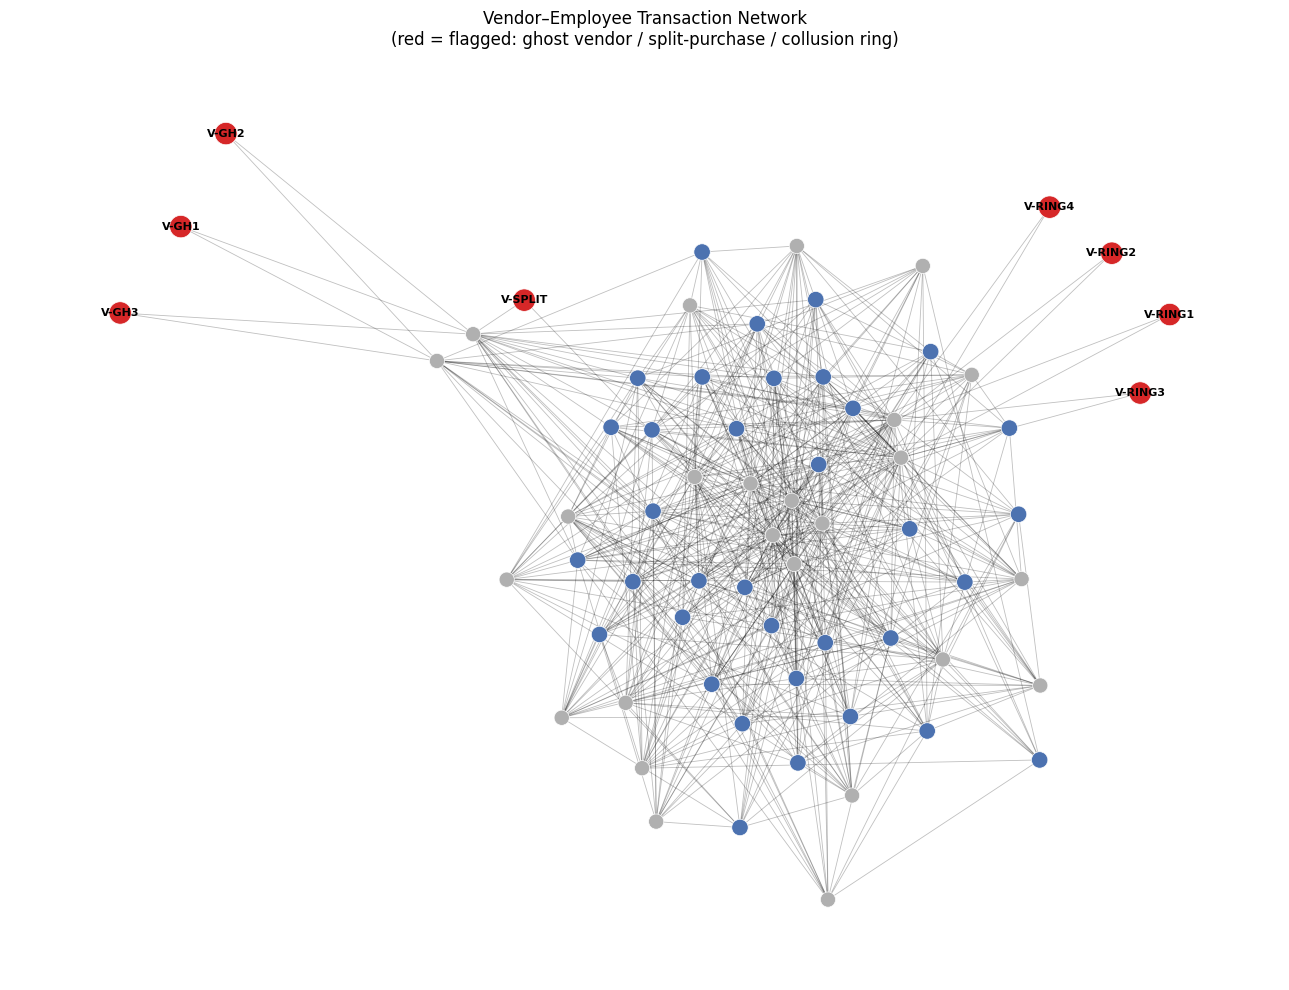

In [7]:
import matplotlib.pyplot as plt

flagged_ids = set(vstats[vstats["ghost_score"] >= 3]["vendor_id"]) | {"V-SPLIT"} | ring_vendor_ids

node_colors = []
node_sizes = []
for n, d in G.nodes(data=True):
    if d["kind"] == "employee":
        node_colors.append("#B0B0B0")
        node_sizes.append(120)
    elif n in flagged_ids:
        node_colors.append("#D62728")
        node_sizes.append(260)
    else:
        node_colors.append("#4C72B0")
        node_sizes.append(140)

plt.figure(figsize=(13, 10))
pos = nx.spring_layout(G, k=0.35, seed=7)
nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.6)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, linewidths=0.5, edgecolors="white")
labels = {n: n for n in flagged_ids}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight="bold")
plt.title("Vendor–Employee Transaction Network\n(red = flagged: ghost vendor / split-purchase / collusion ring)")
plt.axis("off")
plt.tight_layout()
plt.savefig("output/full_network.png", dpi=160)
plt.show()


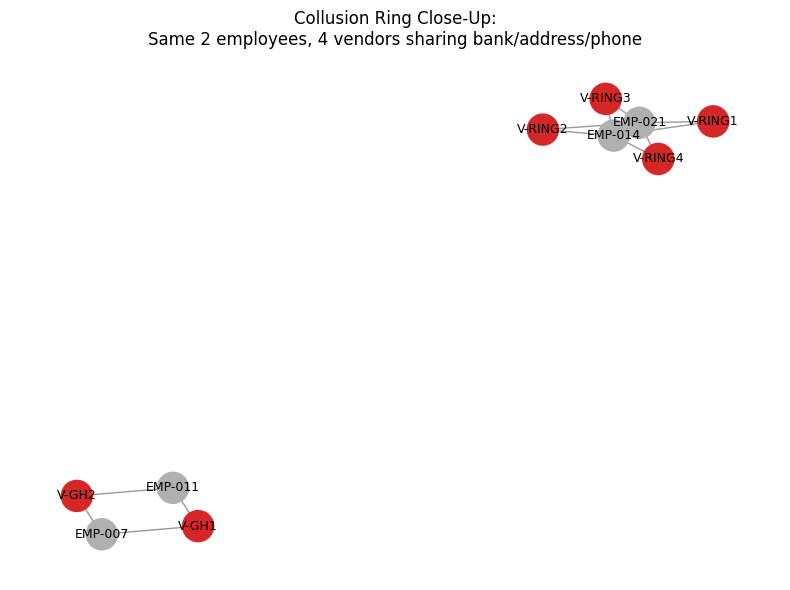

In [8]:
# Zoomed view: just the collusion ring + the employees connected to it
sub_nodes = ring_vendor_ids | set(pair_counts["requester_id"]) | set(pair_counts["approver_id"])
SG = G.subgraph(sub_nodes)

plt.figure(figsize=(8, 6))
pos2 = nx.spring_layout(SG, seed=3)
colors2 = ["#D62728" if n in ring_vendor_ids else "#B0B0B0" for n in SG.nodes()]
nx.draw_networkx_edges(SG, pos2, alpha=0.4)
nx.draw_networkx_nodes(SG, pos2, node_color=colors2, node_size=500)
nx.draw_networkx_labels(SG, pos2, font_size=9)
plt.title("Collusion Ring Close-Up:\nSame 2 employees, 4 vendors sharing bank/address/phone")
plt.axis("off")
plt.tight_layout()
plt.savefig("output/collusion_ring.png", dpi=160)
plt.show()


## 7. Summary — the red-flag checklist

| Pattern | What the ledger shows you | What the network shows you |
|---|---|---|
| Ghost vendor | Small, unremarkable dollar amounts | One requester + one approver, always; missing tax ID; PO Box |
| Split purchase | Each invoice individually clears approval | Repeated bursts from one requester to one vendor, summing over the threshold |
| Collusion ring | Four distinct, validly formatted vendor records | Shared bank account/address/phone links them; same 1–2 employees run all the traffic |

**Takeaway for the case study discussion:** none of these three patterns
require a single fraudulent-looking invoice amount. Each hides in
*relationships and repetition* — exactly what graph structure, not columnar
filtering, is built to surface. In production this becomes a **standing
control**: score every vendor/employee pair nightly, and route anything
crossing a risk threshold to AP/audit for review *before* the payment run,
not after.

### Discussion questions for the group
1. Which of your current AP controls would catch each of these three
   patterns today — and which wouldn't?
2. What data would you need to add (e.g., vendor bank account, IP/device at
   vendor onboarding, employee HR relationships) to run this in your
   environment?
3. Where would you set the human-review threshold so this augments, rather
   than replaces, the AP team's judgment?
